In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import pandas as pd

V1_PATH = "/content/drive/MyDrive/frozen_dataset/dataset_v1_full.csv"
assert os.path.exists(V1_PATH), f"Couldn't find {V1_PATH} — check the Day 12 copy step."

df = pd.read_csv(V1_PATH)
print(f"Loaded Dataset V1: {df.shape}")
df.head()

RATED_CAPACITY_AH = 3.0

Loaded Dataset V1: (104560, 19)


In [3]:
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.sort_values(["file_id", "timestamp"]).reset_index(drop=True)

In [4]:
g = df.groupby("file_id", group_keys=False)


df["c_rate"] = df["current_a"] / RATED_CAPACITY_AH


df["temp_rise_c"] = df["cell_temp_c"] - df["ambient_temp_c"]

df["voltage_lag1"] = g["voltage_v"].shift(1)
df["current_lag1"] = g["current_a"].shift(1)


df["voltage_delta1"] = df["voltage_v"] - df["voltage_lag1"]
df["current_delta1"] = df["current_a"] - df["current_lag1"]


ROLL_WINDOW = 5
df["voltage_roll_mean5"] = g["voltage_v"].apply(lambda s: s.rolling(ROLL_WINDOW, min_periods=1).mean())
df["voltage_roll_std5"] = g["voltage_v"].apply(lambda s: s.rolling(ROLL_WINDOW, min_periods=1).std())
df["current_roll_mean5"] = g["current_a"].apply(lambda s: s.rolling(ROLL_WINDOW, min_periods=1).mean())
df["current_roll_std5"] = g["current_a"].apply(lambda s: s.rolling(ROLL_WINDOW, min_periods=1).std())


df["current_temp_interaction"] = df["current_a"] * df["cell_temp_c"]

ENGINEERED_NEW_COLS = [
    "c_rate", "temp_rise_c", "voltage_lag1", "current_lag1",
    "voltage_delta1", "current_delta1", "voltage_roll_mean5",
    "voltage_roll_std5", "current_roll_mean5", "current_roll_std5",
    "current_temp_interaction",
]


before = len(df)
df = df.dropna(subset=ENGINEERED_NEW_COLS)
print(f"Dropped {before - len(df)} warm-up rows (first sample of each file, "
      f"where lag/rolling features aren't yet defined).")
print(f"Shape after feature engineering: {df.shape}")


Dropped 35 warm-up rows (first sample of each file, where lag/rolling features aren't yet defined).
Shape after feature engineering: (104525, 30)


In [5]:
RAW_FEATURES = ["voltage_v", "current_a", "cell_temp_c", "power_w", "ambient_temp_c"]
ENGINEERED_FEATURES = RAW_FEATURES + ENGINEERED_NEW_COLS
TARGET_COLUMN = "soc_percent"

print(f"\nRAW feature set ({len(RAW_FEATURES)}): {RAW_FEATURES}")
print(f"ENGINEERED feature set ({len(ENGINEERED_FEATURES)}): {ENGINEERED_FEATURES}")


RAW feature set (5): ['voltage_v', 'current_a', 'cell_temp_c', 'power_w', 'ambient_temp_c']
ENGINEERED feature set (16): ['voltage_v', 'current_a', 'cell_temp_c', 'power_w', 'ambient_temp_c', 'c_rate', 'temp_rise_c', 'voltage_lag1', 'current_lag1', 'voltage_delta1', 'current_delta1', 'voltage_roll_mean5', 'voltage_roll_std5', 'current_roll_mean5', 'current_roll_std5', 'current_temp_interaction']


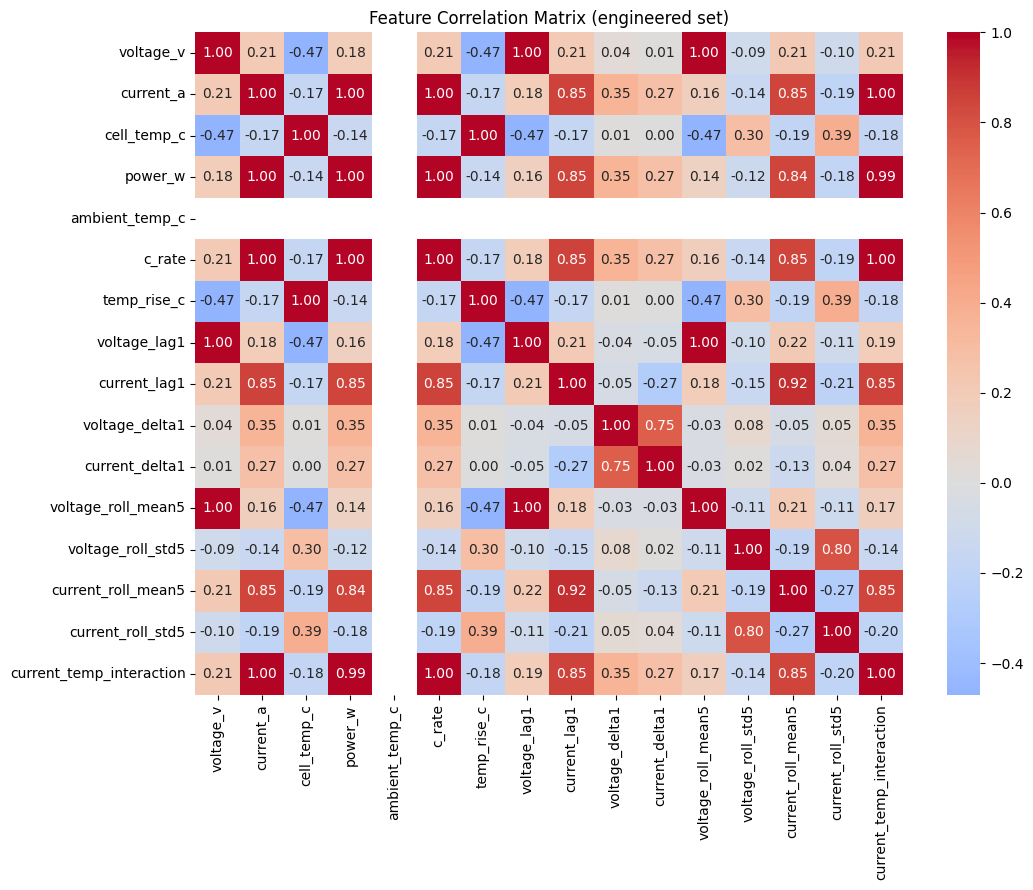


Feature pairs with |correlation| > 0.9:
  voltage_v <-> voltage_lag1: 0.997
  voltage_v <-> voltage_roll_mean5: 0.996
  current_a <-> power_w: 0.996
  current_a <-> c_rate: 1.000
  current_a <-> current_temp_interaction: 1.000
  cell_temp_c <-> temp_rise_c: 1.000
  power_w <-> c_rate: 0.996
  power_w <-> current_temp_interaction: 0.995
  c_rate <-> current_temp_interaction: 1.000
  voltage_lag1 <-> voltage_roll_mean5: 0.998
  current_lag1 <-> current_roll_mean5: 0.918


/tmp/ipykernel_1171/3786188454.py:32: UserWarning: The design matrix is poorly conditioned (condition number=4.26e+17). VIF calculations may be numerically unstable.
  "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(ENGINEERED_FEATURES))]
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared
/usr/local/lib/python3.13/dist


Variance Inflation Factor (VIF > 10 = high multicollinearity):
                 feature          VIF
               voltage_v 1.000800e+15
               current_a 1.000800e+15
             cell_temp_c 1.000800e+15
                  c_rate 1.000800e+15
            voltage_lag1 1.000800e+15
             temp_rise_c 1.000800e+15
          voltage_delta1 1.000800e+15
            current_lag1 1.000800e+15
          current_delta1 1.000800e+15
current_temp_interaction 2.856861e+03
      voltage_roll_mean5 8.718584e+02
                 power_w 1.865439e+02
          ambient_temp_c 9.525688e+01
      current_roll_mean5 2.084192e+01
       current_roll_std5 3.208819e+00
       voltage_roll_std5 3.045120e+00

Features flagged for review/removal due to VIF > 10: ['voltage_v', 'current_a', 'cell_temp_c', 'c_rate', 'voltage_lag1', 'temp_rise_c', 'voltage_delta1', 'current_lag1', 'current_delta1', 'current_temp_interaction', 'voltage_roll_mean5', 'power_w', 'ambient_temp_c', 'current_roll_mean5']


/usr/local/lib/python3.13/dist-packages/statsmodels/stats/outliers_influence.py:235: SingularMatrixWarning: The design matrix is rank-deficient. The model parameters are not uniquely determined.
  r_sq = OLS(x_i, x_noti).fit().rsquared


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.outliers_influence import variance_inflation_factor

corr_matrix = df[ENGINEERED_FEATURES].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Feature Correlation Matrix (engineered set)")
plt.tight_layout()
plt.show()


CORR_THRESHOLD = 0.9
print(f"\nFeature pairs with |correlation| > {CORR_THRESHOLD}:")
pairs_flagged = []
for i in range(len(ENGINEERED_FEATURES)):
    for j in range(i + 1, len(ENGINEERED_FEATURES)):
        c1, c2 = ENGINEERED_FEATURES[i], ENGINEERED_FEATURES[j]
        val = corr_matrix.loc[c1, c2]
        if abs(val) > CORR_THRESHOLD:
            pairs_flagged.append((c1, c2, round(val, 3)))
            print(f"  {c1} <-> {c2}: {val:.3f}")
if not pairs_flagged:
    print("  (none)")


vif_df = df[ENGINEERED_FEATURES].dropna()
vif_data = pd.DataFrame({
    "feature": ENGINEERED_FEATURES,
    "VIF": [variance_inflation_factor(vif_df.values, i) for i in range(len(ENGINEERED_FEATURES))]
}).sort_values("VIF", ascending=False)

print("\nVariance Inflation Factor (VIF > 10 = high multicollinearity):")
print(vif_data.to_string(index=False))


HIGH_VIF_TO_DROP = vif_data[vif_data["VIF"] > 10]["feature"].tolist()
print(f"\nFeatures flagged for review/removal due to VIF > 10: {HIGH_VIF_TO_DROP}")

FINAL_ENGINEERED_FEATURES = [c for c in ENGINEERED_FEATURES if c not in HIGH_VIF_TO_DROP]
print(f"Final engineered feature set after redundancy pruning ({len(FINAL_ENGINEERED_FEATURES)}): "
      f"{FINAL_ENGINEERED_FEATURES}")


In [7]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(df, groups=df["file_id"]))
df_train, df_test = df.iloc[train_idx], df.iloc[test_idx]

print(f"\nTrain shape: {df_train.shape}, Test shape: {df_test.shape}")
print("Split grouped by file_id — same reasoning as Day 12: rows within a "
      "drive cycle are highly autocorrelated, so whole files must be kept "
      "together on one side of the split.")


Train shape: (76764, 30), Test shape: (27761, 30)
Split grouped by file_id — same reasoning as Day 12: rows within a drive cycle are highly autocorrelated, so whole files must be kept together on one side of the split.


In [8]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score

def evaluate_feature_set(feature_cols, label):
    X_train, y_train = df_train[feature_cols], df_train[TARGET_COLUMN]
    X_test, y_test = df_test[feature_cols], df_test[TARGET_COLUMN]

    results = {}
    for model_name, model in [
        ("LinearRegression", LinearRegression()),
        ("RandomForest", RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)),
    ]:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mae = mean_absolute_error(y_test, preds)
        r2 = r2_score(y_test, preds)
        results[model_name] = {"MAE": mae, "R2": r2}
        print(f"[{label}] {model_name}: MAE={mae:.3f} SOC%, R2={r2:.4f}")
    return results

print("\n===== RAW FEATURES =====")
raw_results = evaluate_feature_set(RAW_FEATURES, "RAW")

print("\n===== ENGINEERED FEATURES =====")
eng_results = evaluate_feature_set(FINAL_ENGINEERED_FEATURES, "ENGINEERED")



===== RAW FEATURES =====
[RAW] LinearRegression: MAE=3.471 SOC%, R2=0.9712
[RAW] RandomForest: MAE=3.163 SOC%, R2=0.8530

===== ENGINEERED FEATURES =====
[ENGINEERED] LinearRegression: MAE=23.193 SOC%, R2=-0.0681
[ENGINEERED] RandomForest: MAE=22.901 SOC%, R2=-0.1460


In [9]:
comparison = pd.DataFrame({
    "Raw_MAE": {m: raw_results[m]["MAE"] for m in raw_results},
    "Engineered_MAE": {m: eng_results[m]["MAE"] for m in eng_results},
    "Raw_R2": {m: raw_results[m]["R2"] for m in raw_results},
    "Engineered_R2": {m: eng_results[m]["R2"] for m in eng_results},
})
comparison["MAE_improvement_%"] = 100 * (comparison["Raw_MAE"] - comparison["Engineered_MAE"]) / comparison["Raw_MAE"]
print("\n===== RAW vs ENGINEERED COMPARISON =====")
print(comparison.to_string())


===== RAW vs ENGINEERED COMPARISON =====
                   Raw_MAE  Engineered_MAE    Raw_R2  Engineered_R2  MAE_improvement_%
LinearRegression  3.470759       23.193436  0.971168      -0.068143         -568.25267
RandomForest      3.163406       22.901408  0.853029      -0.146045         -623.94770


In [10]:
FEATURE_DOCUMENTATION = {
    "voltage_v": "Direct sensor reading, available instantly at inference.",
    "current_a": "Direct sensor reading, available instantly at inference.",
    "cell_temp_c": "Direct sensor reading, available instantly at inference.",
    "power_w": "Deterministic product of two instantaneous readings (V*I); no future or label info.",
    "ambient_temp_c": "Set by the test environment / an external ambient sensor; known in real time.",
    "c_rate": "Current normalized by a FIXED, known constant (rated capacity) — not derived from the target.",
    "temp_rise_c": "Difference of two simultaneous sensor readings (cell vs ambient); no future info.",
    "voltage_lag1": "Previous sensor sample — already recorded by the time of the current prediction.",
    "current_lag1": "Previous sensor sample — already recorded by the time of the current prediction.",
    "voltage_delta1": "Difference between current and previous sample — purely historical.",
    "current_delta1": "Difference between current and previous sample — purely historical.",
    "voltage_roll_mean5": "Rolling stat over current + past 4 samples within the same file — causal.",
    "voltage_roll_std5": "Rolling stat over current + past 4 samples within the same file — causal.",
    "current_roll_mean5": "Rolling stat over current + past 4 samples within the same file — causal.",
    "current_roll_std5": "Rolling stat over current + past 4 samples within the same file — causal.",
    "current_temp_interaction": "Product of two simultaneous sensor readings; standard ECM interaction term.",
}

print("\n===== FEATURE VALIDITY DOCUMENTATION =====")
for feat in FINAL_ENGINEERED_FEATURES:
    print(f" - {feat}: {FEATURE_DOCUMENTATION.get(feat, 'NEEDS DOCUMENTATION')}")



===== FEATURE VALIDITY DOCUMENTATION =====
 - voltage_roll_std5: Rolling stat over current + past 4 samples within the same file — causal.
 - current_roll_std5: Rolling stat over current + past 4 samples within the same file — causal.


In [11]:
import datetime

os.makedirs("feature_engineering_v1", exist_ok=True)

df[["file_id", "timestamp", TARGET_COLUMN] + FINAL_ENGINEERED_FEATURES].to_csv(
    "feature_engineering_v1/engineered_dataset.csv", index=False)
comparison.to_csv("feature_engineering_v1/raw_vs_engineered_comparison.csv")
vif_data.to_csv("feature_engineering_v1/vif_report.csv", index=False)

with open("feature_engineering_v1/summary.txt", "w") as f:
    f.write("Day 13 — Feature Engineering & Selection\n")
    f.write(f"Generated: {datetime.datetime.now()}\n\n")
    f.write(f"Raw feature set: {RAW_FEATURES}\n")
    f.write(f"Engineered feature set (post redundancy pruning): {FINAL_ENGINEERED_FEATURES}\n")
    f.write(f"Features dropped for high VIF (>10): {HIGH_VIF_TO_DROP}\n")
    f.write(f"Highly correlated pairs (>{CORR_THRESHOLD}): {pairs_flagged}\n\n")
    f.write("Raw vs Engineered performance:\n")
    f.write(comparison.to_string())
    f.write("\n\nFeature validity documentation:\n")
    for feat in FINAL_ENGINEERED_FEATURES:
        f.write(f" - {feat}: {FEATURE_DOCUMENTATION.get(feat, 'NEEDS DOCUMENTATION')}\n")

print("\n✅ Feature engineering artifacts saved in 'feature_engineering_v1/':")
for f in os.listdir("feature_engineering_v1"):
    print(" -", f)



✅ Feature engineering artifacts saved in 'feature_engineering_v1/':
 - vif_report.csv
 - raw_vs_engineered_comparison.csv
 - summary.txt
 - engineered_dataset.csv
